In [92]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [12]:
dataset = pd.read_csv("Loan_Prediction.csv")

In [13]:
dataset.head(5)

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


In [15]:
dataset["Risk_Flag"].value_counts()

Risk_Flag
0    221004
1     30996
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

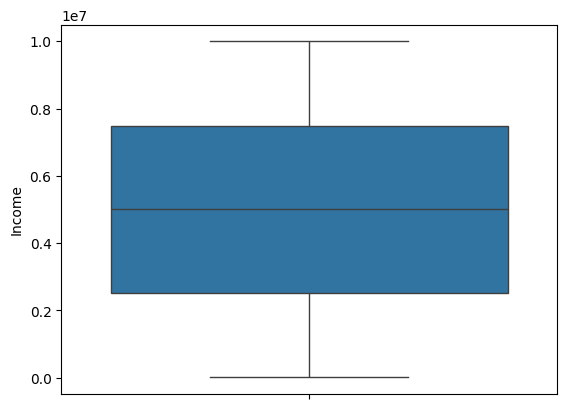

In [16]:
sns.boxplot(dataset["Income"])
plt.show

In [74]:
cat_cols = ["Married/Single","House_Ownership","Car_Ownership","Profession","CITY", "STATE"]

In [85]:
dataset = dataset.loc[:, ~dataset.columns.duplicated()]
dataset

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Married/Single_single,House_Ownership_owned,House_Ownership_rented,...,STATE_Uttar_Pradesh,STATE_Uttar_Pradesh[5],STATE_Uttarakhand,STATE_West_Bengal,Married/Single_married,House_Ownership_norent_noown,Car_Ownership_no,Profession_Air_traffic_controller,CITY_Adoni,STATE_Andhra_Pradesh
0,1,1303834,23,3,3,13,0,True,False,True,...,False,False,False,False,False,False,True,False,False,False
1,2,7574516,40,10,9,13,0,True,False,True,...,False,False,False,False,False,False,True,False,False,False
2,3,3991815,66,4,4,10,0,False,False,True,...,False,False,False,False,True,False,True,False,False,False
3,4,6256451,41,2,2,12,1,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,5,5768871,47,11,3,14,1,True,False,True,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251995,251996,8154883,43,13,6,11,0,True,False,True,...,False,False,False,True,False,False,True,False,False,False
251996,251997,2843572,26,10,6,11,0,True,False,True,...,False,False,False,False,False,False,True,False,False,False
251997,251998,4522448,46,7,7,12,0,True,False,True,...,False,False,False,False,False,False,True,False,False,False
251998,251999,6507128,45,0,0,10,0,True,False,True,...,False,False,False,False,False,False,True,False,False,False


In [86]:
x = dataset.drop("Risk_Flag", axis=1)
y = dataset["Risk_Flag"]

In [87]:
ru = RandomUnderSampler()
ru_x, ru_y = ru.fit_resample(x, y)

In [88]:
y.shape

(252000,)

In [89]:
ru_y.value_counts()

Risk_Flag
0    30996
1    30996
Name: count, dtype: int64

In [81]:
x_train, x_test, y_train, y_test = train_test_split(ru_x, ru_y, test_size=0.2, random_state=42)


In [82]:
lr = LogisticRegression()

In [83]:
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [84]:
lr.score(x_test, y_test)

0.5319783853536576

In [91]:
lr.predict(x_test.iloc[[0]])

array([1], dtype=int64)

<function matplotlib.pyplot.show(close=None, block=None)>

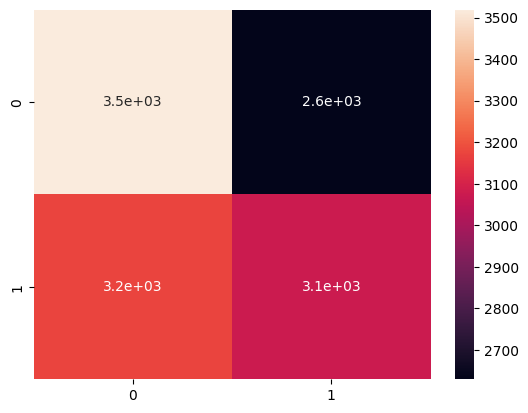

In [96]:
cf = confusion_matrix(y_test, lr.predict(x_test))
sns.heatmap(cf, annot=True)
plt.show

In [99]:
ps = precision_score(y_test, lr.predict(x_test))
ps*100

53.92569225376796

In [100]:
rs = recall_score(y_test, lr.predict(x_test))
rs*100

49.224124140137576

In [101]:
f1s = f1_score(y_test, lr.predict(x_test))
f1s*100

51.46775947143932